In [615]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from macrohet import visualise, colours
from tqdm.auto import tqdm
import os
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import gridspec
from tqdm import tqdm
import os
from matplotlib.patches import Rectangle
from matplotlib.patches import Patch
import webbrowser

from PIL import Image
plt.rcParams['font.family'] = 'Nimbus Sans'
plt.rcParams['font.size'] = 14
visualise.set_plotting_defaults()
expanded_piyg = colours.expanded_piyg
# Conversion factor
meters_per_pixel = 1.4949402023919043E-07  # Micrometers per pixel
micrometers_per_pixel = meters_per_pixel*1E6 # Micrometers per pixel

def replace_ytick_labels(ax, old_label, new_label):
    """
    Replace y-axis tick labels in a given matplotlib Axes object.
    
    Parameters:
    ax (matplotlib.axes.Axes): The axes on which to replace y-tick labels.
    old_label (str): The label to be replaced.
    new_label (str): The new label to replace the old label with.
    """
    # Get current y-tick labels
    yticks = ax.get_yticks()
    yticklabels = [label.get_text() for label in ax.get_yticklabels()]

    # Replace the old label with the new label
    yticklabels = [new_label if label == old_label else label for label in yticklabels]

    # Set the new y-tick labels
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels)

### set plotting parameters
# Input figure size in millimeters
width_mm = 280  # for example, 180 mm
height_mm = 100  # for example, 80 mm
# Convert millimeters to inches (1 inch = 25.4 mm)
width_in = width_mm / 25.4
height_in = height_mm / 25.4

### set biological parameters
# Step 1: Bin the Doubling Times into categories
bins = [0, 16, 24, float('inf')]  # Define the bins: <20, 20-24, >24
labels = ['Fast', 'Normal', 'Slow']  # Labels for each bin
# Define the desired order with CTRL at the top
strain_order = ['CTRL', 'PZA', 'INH', 'RIF']

Helvetica not found. Using Nimbus Sans font.
Default plotting aesthetic loaded.


In [616]:
# df = pd.read_pickle('/Volumes/OPERA2/Nathan/macrohet_syno/results/dfs/sc_df.pkl')
df = pd.read_pickle('/mnt/SYNO/macrohet_syno/results/dfs/sc_df.pkl')


In [5]:
# Prepare the subset DataFrame as before
subset_df = df[(df['r2'] >= 0.8) 
             & (df['Edge Status'] == False) 
             & (df['Strain'] != 'UNI')
             & (df['Compound'] == 'CTRL')
             & (df['mtb_origin'] != 'Junk')
            & ~((df['Experiment ID'] == 'ND0004') & (df['Concentration'].isin(['EC0', 'EC50']))) # exclude unchecked ND4
               ].drop_duplicates(subset=['ID'])
subset_df = subset_df.explode('Doubling Times')
subset_df['Doubling Times'] = pd.to_numeric(subset_df['Doubling Times'], errors='coerce')
subset_df = subset_df[subset_df['Doubling Times'].notna()]
subset_df = subset_df[subset_df['Doubling Times'] >= 0]
Ncell = len(subset_df.drop_duplicates('ID'))
print(f'N(dt)={len(subset_df)}, N(cell)={Ncell}')

subset_df['Growth Category'] = pd.cut(subset_df['Doubling Times'], bins=bins, labels=labels, right=False)


N(dt)=1131, N(cell)=514


/tmp/ipykernel_306998/1819456718.py:9: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_306998/1819456718.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_counts = subset_df.groupby(['Strain', 'Growth Category']).size()  # Count occurrences per strain and category


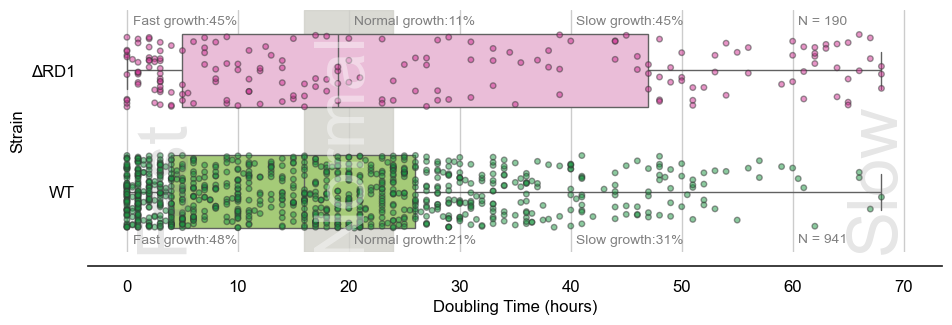

In [6]:
# Step 2: Plot the boxplot and stripplot (same as before)
f, ax = plt.subplots(figsize=(width_in, height_in/1.25))

sns.boxplot(
    data=subset_df, x="Doubling Times", y="Strain", hue="Strain", 
    whis=[0, 100], width=.6, palette=[expanded_piyg[1], expanded_piyg[-2]]
)

sns.stripplot(
    data=subset_df, x="Doubling Times", y="Strain", size=4, hue="Strain", 
    palette=[expanded_piyg[0], expanded_piyg[-1]], alpha=0.5,
    edgecolor='gray', linewidth=1, jitter=0.3,
)


# Step 4: Calculate and add count and percentage labels for each strain in each growth category
total_counts = subset_df.groupby(['Strain', 'Growth Category']).size()  # Count occurrences per strain and category
strain_totals = subset_df['Strain'].value_counts()  # Total counts per strain


for strain in subset_df['Strain'].unique():
    for category in labels:
        # Get the count for the current strain and category
        count = total_counts.get((strain, category), 0)
        # Calculate the percentage for this strain in this category
        percentage = (count / strain_totals[strain]) * 100
        # Add the count and percentage label on the plot
        ax.text(
            0.5 + labels.index(category)*20 , (-0.4 if strain == 'WT' else 1.4), # Adjust position based on strain
            f"{category} growth:{percentage:.0f}%", 
            color="gray", fontsize=10, va='center', ha='left'
        )

    ax.text(
            0.5 + (labels.index(category)+1)*20 , (-0.4 if strain == 'WT' else 1.4), # Adjust position based on strain
            f"N = {strain_totals[strain]}", 
            color="gray", fontsize=10, va='center', ha='left'
            )

# Step 5: Adjust y-limits to bring boxplots closer together
ax.set_ylim(-0.5, 1.5)  # Compresses the space between the two strains

# Add shaded regions for each growth category
ax.axvspan(0, bins[1], color=expanded_piyg[3], alpha=0, label='Fast (<20h)')
ax.axvspan(bins[1], bins[2], color=expanded_piyg[3], alpha=0.8, label='Normal (20-28h)')
ax.axvspan(bins[2], 70, color=expanded_piyg[3], alpha=0., label='Slow (>28h)')

# Step 6: Add vertical text labels within each category region
ax.text(bins[0] + 0.5, -0.4, 'Fast', fontsize=50, color='gray', alpha=0.2, ha='left', va='baseline', rotation=90)
ax.text(bins[1] + 0.5, -0.4, 'Normal', fontsize=50, color='white', alpha=0.4, ha='left', va='baseline', rotation=90)
ax.text(70 + 0.5, -0.4, 'Slow', fontsize=50, color='gray', alpha=0.2, ha='right', va='baseline', rotation=90)


replace_ytick_labels(ax, old_label='RD1', new_label='ΔRD1')

# Final tweaks
ax.xaxis.grid(True)
sns.despine(offset=10, left=True)

plt.xlabel('Doubling Time (hours)')
# Save the figure
# plt.savefig(os.path.join(output_dir, 'wt_rd1_dt_unfiltered_growth_cats.pdf'), bbox_inches='tight',  dpi=314)
plt.show()


/tmp/ipykernel_306998/1037978102.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  growth_speed_counts = subset_df.groupby(['Strain', 'Growth Category']).size().unstack(fill_value=0)
/tmp/ipykernel_306998/1037978102.py:68: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rectangle((0, 0), bbox_w, bbox_h, color=expanded_piyg[1], edgecolor='none'),  # Color for the first category
/tmp/ipykernel_306998/1037978102.py:69: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rectangle((0, 0), bbox_w, bbox_h, color=expanded_piyg[-2], edgecolor='none'),  # Color for the second category
/tmp/ipykernel_306998/1037978102.py:70: UserWarning: Setting the 'color' property will override the edgecolor or facecolor prope

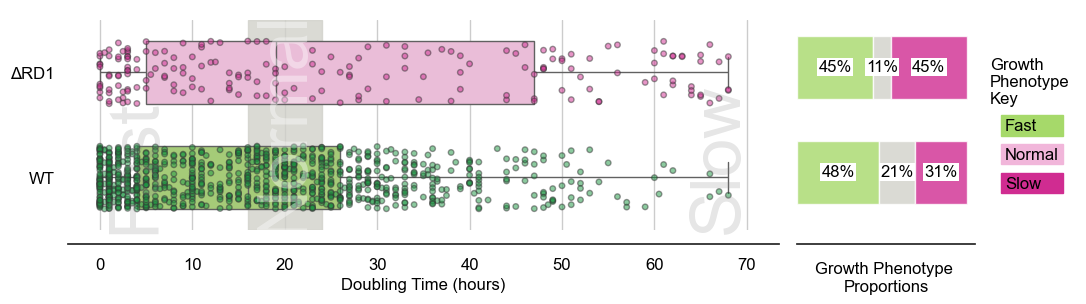

In [610]:
colors = {'WT':expanded_piyg[1], 'RD1':expanded_piyg[-1], 'Fast':expanded_piyg[0], 'Normal':expanded_piyg[3], 'Slow':expanded_piyg[-1]}
df['Video Link'] = df['ID'].apply(lambda ID: f"https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/videos/{ID}_glimpse_graph.mp4")
# add image links
df['Image Link'] = df['Image Link'] = df.apply(
    # lambda row: f"https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/{row['ID']}_t{row['Time (hours)']}.png",
    # lambda row: f"https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/glimpse_frames/4108.4.3.ND0003/frame_067.png",
    lambda row: f"https://macrohet.s3.eu-west-2.amazonaws.com/macrohet.glimpses/glimpse_frames/{row['ID']}/frame_{int(row['Time (hours)']):03d}.png",
    axis=1
)

/tmp/ipykernel_306998/2345058125.py:75: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



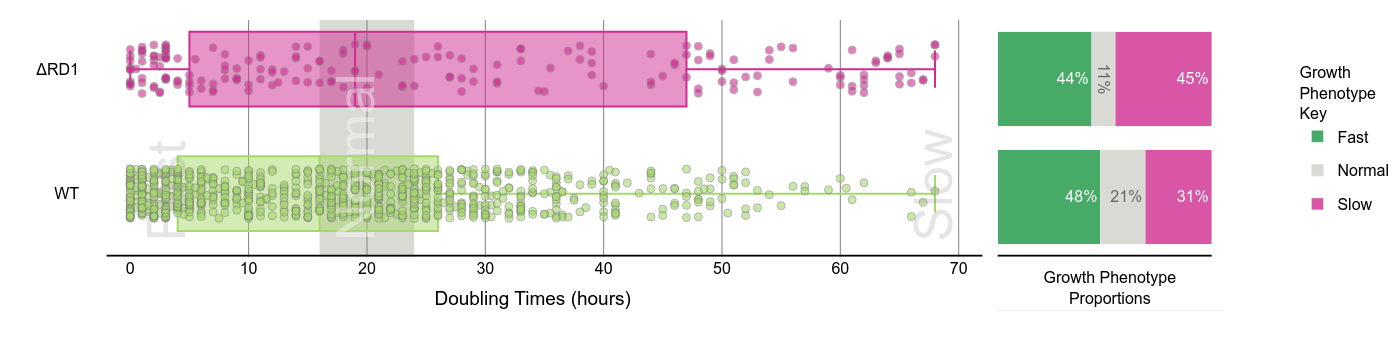

In [613]:
from dash import Dash, dcc, html, Input, Output
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import math

def custom_round(value, precision):
    return round(value + 1e-10, precision)
from dash import Dash, dcc, html, Input, Output
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import math

def custom_round(value, precision):
    return round(value + 1e-10, precision)

# Create a subplot with two vertical sections and an additional row for the title
fig = make_subplots(
    rows=2, cols=2,
    column_widths=[0.8, 0.2],
    row_heights=[0.95, 0.4],  # Add small row at bottom for title
    horizontal_spacing=0.01,
    vertical_spacing=0.01
)

# First section: Boxplots, stripplots, and shaded regions
for strain in subset_df['Strain'].unique():
    strain_data = subset_df[subset_df['Strain'] == strain]
    jitter = np.random.uniform(-0.2, 0.2, size=len(strain_data))
    strain_numeric = np.where(subset_df['Strain'].unique() == strain)[0][0]
    
    # Add boxplot trace
    fig.add_trace(go.Box(
        x=strain_data['Doubling Times'],
        y=[strain_numeric] * len(strain_data),
        name=strain,
        marker_color=colors[strain],
        hoverinfo='none',
        boxmean=False,
        orientation="h",
        width=0.6,
        boxpoints=False,
        showlegend=False
    ), row=1, col=1)
    
    # Add stripplot trace
    fig.add_trace(go.Scatter(
        x=strain_data['Doubling Times'],
        y=[strain_numeric] * len(strain_data)+ jitter,
        mode="markers",
        name=strain,
        marker=dict(color=colors[strain], size=8, opacity=0.6, line=dict(color='gray', width=1)),
        customdata=strain_data['Video Link'],
        hoverinfo="text",
        text=[
            f"<b>Doubling Time:</b> {x:.2f}<br><b>Strain:</b> {strain}<br>"
            for x in strain_data['Doubling Times']
        ],
        showlegend=False
    ), row=1, col=1)

# Add shaded regions
fig.add_vrect(x0=0, x1=bins[1], fillcolor=expanded_piyg[3], opacity=0, layer="below", line_width=0, row=1, col=1)
fig.add_vrect(x0=bins[1], x1=bins[2], fillcolor=expanded_piyg[3], opacity=0.8, layer="below", line_width=0, row=1, col=1)
fig.add_vrect(x0=bins[2], x1=70, fillcolor=expanded_piyg[3], opacity=0, layer="below", line_width=0, row=1, col=1)

# Add vertical text labels within each category region
fig.add_annotation(x=bins[0] + 0.5, y=-0.4, text='Fast', font=dict(size=52, color='gray'), opacity=0.2, 
                  xanchor='left', yanchor='bottom', showarrow=False, textangle=-90, row=1, col=1)
fig.add_annotation(x=bins[1] + 0.5, y=-0.4, text='Normal', font=dict(size=52, color='white'), opacity=0.4, 
                  xanchor='left', yanchor='bottom', showarrow=False, textangle=-90, row=1, col=1)
fig.add_annotation(x=70 + 0.5, y=-0.4, text='Slow', font=dict(size=52, color='gray'), opacity=0.2, 
                  xanchor='right', yanchor='bottom', showarrow=False, textangle=-90, row=1, col=1)

# Calculate and add growth speed percentages
growth_speed_counts = subset_df.groupby(['Strain', 'Growth Category']).size().unstack(fill_value=0)
growth_speed_percentages = growth_speed_counts.div(growth_speed_counts.sum(axis=1), axis=0).reindex(index=subset_df['Strain'].unique())

# Add stacked bar chart
for i, strain in enumerate(subset_df['Strain'].unique()):
    percentages = growth_speed_percentages.iloc[i]
    rounded_percentages = [custom_round(p, 2) for p in percentages]
    
    total = sum(rounded_percentages)
    if total != 1:
        diff = 1 - total
        max_idx = rounded_percentages.index(max(rounded_percentages))
        rounded_percentages[max_idx] += diff
    
    for j, (category, percentage) in enumerate(zip(growth_speed_percentages.columns, rounded_percentages)):
        fig.add_trace(go.Bar(
            x=[percentage],
            y=[strain],
            orientation='h',
            marker_color=colors[category],
            opacity=0.8,
            showlegend=i==0,
            legendgroup=category,
            name=category,
            text=[f"{round(percentage * 100)}%"],
            textposition='inside',
            hoverinfo='text',
            hovertext=[f"{strain}<br>{category}: {round(percentage * 100)}%"]
        ), row=1, col=2)

# Add title text as a bar trace in the bottom row
fig.add_trace(go.Bar(
    x=[1],
    y=[-0],
    width=30,
    marker_color='rgba(0,0,0,0)',  # Transparent
    text=['Growth Phenotype<br>Proportions'],
    textposition='outside',
    textfont=dict(size=16, color='black'),
    showlegend=False,
    hoverinfo='none'
), row=2, col=2)

# Define common font settings
font_settings = dict(
    family='Helvetica, Arial, sans-serif',
    size=16, 
    color='black'
)

# Update layout
fig.update_layout(
    barmode='stack',
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=965,
    margin=dict(b=0, t=20),  # Reduced bottom margin
    font=font_settings,
    legend=dict(
        title='Growth<br>Phenotype<br>Key',
        orientation='v',
        yanchor='middle', y=0.65,
        xanchor='right', x=1.15,
        title_side='top',
        title_font_size=16,
        font=dict(size=16)
    ),
    showlegend=True
)

# Update axes configurations for main plots
axes_updates = {
    (1,1): dict(
        x=dict(
            visible=True,
            tickmode='linear',
            tick0=0,
            dtick=10,
            gridcolor='gray',
            gridwidth=1,
            title_text='Doubling Times (hours)'
        ),
        y=dict(
            ticktext=["WT", "ΔRD1"],
            tickvals=[0, 1]
        )
    ),
    (1,2): dict(
        x=dict(visible=False),
        y=dict(
            ticktext=[],
            tickvals=[]
        )
    )
}

# Apply axes updates
for (row, col), settings in axes_updates.items():
    if 'x' in settings:
        fig.update_xaxes(**settings['x'], row=row, col=col)
    if 'y' in settings:
        fig.update_yaxes(**settings['y'], row=row, col=col)

# Hide axes for the bottom row
fig.update_xaxes(visible=False, row=2, col=1)
fig.update_xaxes(visible=False, row=2, col=2)
fig.update_yaxes(visible=False, row=2, col=1)
fig.update_yaxes(visible=False, row=2, col=2)

# Add horizontal lines
for col, x_range in [(1, (-2, 72)), (2, (0, 1))]:
    fig.add_shape(
        type='line',
        x0=x_range[0], x1=x_range[1],
        y0=-0.5, y1=-0.5,
        line=dict(color='black', width=2),
        row=1, col=col
    )


fig.show()

boxplot = fig

In [331]:
html_template = f"""
    <!DOCTYPE html>
    <html>
    <head>
        <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
        <style>
            .container {{
                width: 80%;
                margin: 0 auto;
            }}
            #plot {{
                width: 100%;
                height: 60vh;
            }}
            .hover-popup {{
                position: absolute;
                background-color: white;
                border: 2px solid white;
                padding: 5px;
                z-index: 1000;
                display: none;
                box-shadow: 0 2px 10px rgba(0,0,0,0.1);
            }}
        </style>
    </head>
    <body>
        <div class="container">
            <div id="plot"></div>
            <div id="hover-popup" class="hover-popup">
                <video id="popup-video" style="width: 400px; height: 400px; 
                       object-fit: cover; object-position: center top;" 
                       autoplay loop muted playsinline></video>
            </div>
        </div>

        <script>
            // Load the Plotly figure
            const figure = {fig.to_json()};
            
            // Initialize the plot
            Plotly.newPlot('plot', figure.data, figure.layout);
            
            const hoverPopup = document.getElementById('hover-popup');
            const popupVideo = document.getElementById('popup-video');
            
            // Add hover event listener for plot
            document.getElementById('plot').on('plotly_hover', function(eventData) {{
                const point = eventData.points[0];
                const videoUrl = point.customdata;
                
                if (videoUrl) {{
                    // Update video source and show popup
                    popupVideo.src = videoUrl;
                    hoverPopup.style.display = 'block';
                    
                    // Position the popup near the cursor
                    const hoverWidth = hoverPopup.offsetWidth;
                    hoverPopup.style.left = `${{eventData.event.clientX - hoverWidth/2}}px`;
                    hoverPopup.style.top = `${{eventData.event.clientY + 20}}px`;
                }}
            }});
            
            // Hide popup on unhover
            document.getElementById('plot').on('plotly_unhover', function() {{
                hoverPopup.style.display = 'none';
                popupVideo.pause();
            }});
        </script>
    </body>
    </html>
"""
# Save the plot to an HTML file with added video functionality
output_file = "../interactive_plots/F2.html"
# Write the HTML file
with open(output_file, "w") as f:
    f.write(html_template)
print(f"Interactive plot with video hover saved to {output_file}")

# After your existing code that saves the file:
webbrowser.open('file://' + os.path.realpath(output_file))

Interactive plot with video hover saved to ../interactive_plots/F2.html


True

### Adding single-cell graphs above it

In [434]:
def save_interactive_growth_curve(fig, output_file):
    """
    Save a Plotly growth curve figure as an HTML file with image popup functionality.
    
    Args:
        fig: Plotly figure object with customdata containing image URLs
        output_file: Path to save the HTML file
    """
    
    html_template = f"""
                    <!DOCTYPE html>
                    <html>
                    <head>
                        <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
                        <style>
                            .container {{
                                width: 80%;
                                margin: 0 auto;
                            }}
                            #plot {{
                                width: 100%;
                                height: 80vh;
                            }}
                            .hover-content {{
                                position: absolute;
                                background-color: white;
                                border: 2px solid white;
                                padding: 5px;
                                z-index: 1000;
                                display: flex;
                                align-items: center;
                                gap: 10px;
                                box-shadow: 0 2px 10px rgba(0,0,0,0.1);
                            }}
                            .hover-content img {{
                                width: 300px;
                                height: auto;
                            }}
                        </style>
                    </head>
                    <body>
                        <div class="container">
                            <div id="plot"></div>
                        </div>
                        <script>
                            // Load the Plotly figure
                            const figure = {fig.to_json()};
                            
                            // Initialize the plot
                            Plotly.newPlot('plot', figure.data, figure.layout);
                            
                            // Add hover event listener
                            document.getElementById('plot').on('plotly_hover', function(eventData) {{
                                const point = eventData.points[0];
                                const imageUrl = point.customdata;
                                
                                if (imageUrl) {{
                                    // Create new hover content
                                    const hoverContent = document.createElement('div');
                                    hoverContent.className = 'hover-content';
                                    hoverContent.innerHTML = `<img src="${{imageUrl}}">`;
                                    document.body.appendChild(hoverContent);
                                    
                                    // Position to the left of the cursor
                                    const hoverWidth = hoverContent.offsetWidth;
                                    hoverContent.style.left = `${{eventData.event.clientX - hoverWidth - 10}}px`;
                                    hoverContent.style.top = `${{eventData.event.clientY - 50}}px`;
                                    
                                    // Remove on unhover
                                    document.getElementById('plot').on('plotly_unhover', function() {{
                                        hoverContent.remove();
                                    }});
                                }}
                            }});
                        </script>
                    </body>
                    </html>
                    """

    # Write the HTML file
    with open(output_file, "w") as f:
        f.write(html_template)
    print(f"Interactive growth curve saved to {output_file}")

200

In [284]:
def add_grid_lines(fig, time_points, populations, x_range=[0, 80], y_range=[0, 300]):
    """Add doubling time grid lines to the figure"""
    for time, population in zip(time_points, populations):
        # Vertical and horizontal lines for each doubling point
        shapes = [
            # Vertical line
            dict(
                type='line',
                x0=time, x1=time,
                y0=y_range[0], y1=y_range[1],
                line=dict(color='gray', width=1, dash='dash'),
                opacity=0.5
            ),
            # Horizontal line
            dict(
                type='line',
                x0=x_range[0], x1=x_range[1],
                y0=population, y1=population,
                line=dict(color='gray', width=1, dash='dash'),
                opacity=0.5
            )
        ]
        fig.update_layout(shapes=list(fig.layout.shapes) + shapes)

def add_axis_lines(fig, x_range=[-2, 80], y_range=[0, 300]):
    """Add solid black axis lines to the figure with offset"""
    axis_shapes = [
        # Y-axis (offset)
        dict(
            type="line",
            xref="x", yref="y",
            x0=-2,  # Fixed position for y-axis
            x1=-2,
            y0=0,  # Extended below to match offset
            y1=300,
            line=dict(color="black", width=2, dash='solid')
        ),
        # X-axis (offset)
        dict(
            type="line",
            xref="x", yref="y",
            x0=0,  # Extended left to match offset
            x1=80,
            y0=-10,  # Fixed position for x-axis
            y1=-10,
            line=dict(color="black", width=2, dash='solid')
        )
    ]
    fig.update_layout(shapes=list(fig.layout.shapes) + axis_shapes)

In [462]:
unique_IDs = list(reversed(unique_IDs))

0 [20. 23. 23.]
1 [26. 36.]
2 [13. 31.]


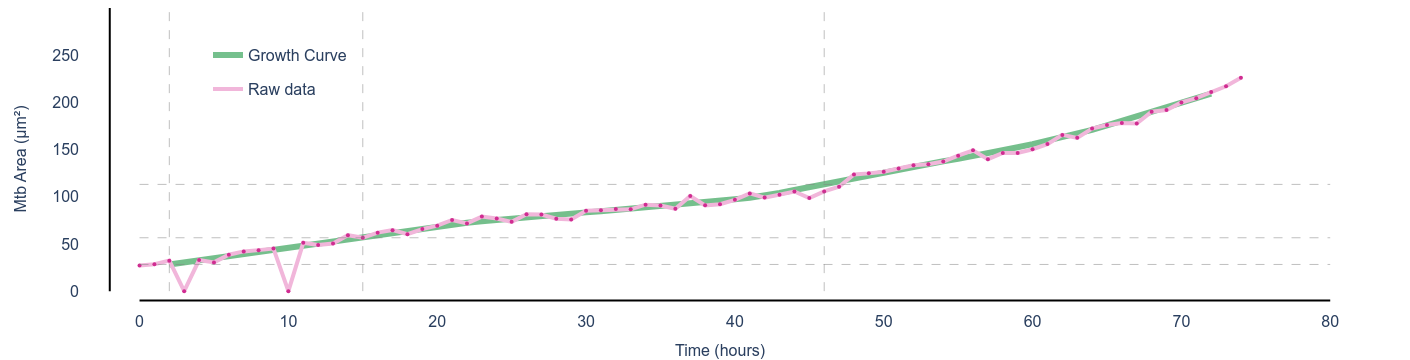

In [612]:


# Example usage for a single curve:
sc_figs = {}
for i, unique_ID in enumerate(unique_IDs):
    sc_df = df[df['ID'] == unique_ID]
    time_model = sc_df['Time Model (hours)'].values
    population_model = sc_df['Mtb Area Model (µm)']
    time_points = sc_df['Time (hours)'].values
    bacterial_population = sc_df['Mtb Area (µm)'].values
    # Calculate doubling points and times
    min_value = max(population_model.min(), 1.92)
    max_value = population_model.max()
    N_series = []
    N_i = min_value
    while N_i <= max_value:
        N_series.append(N_i)
        N_i *= 2
    doubling_time_indices = [np.abs(population_model - value).argmin() for value in N_series]
    doubling_time_points = time_model[doubling_time_indices]
    doubling_times = np.diff(doubling_time_points)
    print(i, doubling_times)
    # Create figure with all traces
    fig = go.Figure()
    
    # Add main trace (model)
    fig.add_trace(go.Scatter(
        x=time_model,
        y=population_model,
        mode='lines',
        line=dict(color=expanded_piyg[0], width=6),
        # name=f"ID: {unique_ID}",
        hoverinfo='skip',
        opacity=0.6,
        showlegend=True, 
        name='Growth Curve'
    ))    
    
    # Add raw data line
    fig.add_trace(go.Scatter(
        x=time_points,
        y=bacterial_population,
        mode='lines',
        line=dict(color=expanded_piyg[-2], width=4),
        showlegend=True,
        legendgroup='raw_data',  # Add this line
        name='Raw data',
        hoverinfo='skip'
    ))
    
    # Add raw data points with hover data
    fig.add_trace(go.Scatter(
        x=time_points,
        y=bacterial_population,
        mode='markers',
        marker=dict(color=expanded_piyg[-1], size=4),
        showlegend=False,
        legendgroup='raw_data',  # Add this line
        hoverinfo='text',
        customdata=sc_df['Image Link'],
        text=[f"<b>ID:</b> {unique_ID}<br><b>Time:</b> {t:.2f} hours<br><b>Mtb Growth Curve:</b> {p:.2f} µm²<br><b>Raw Mtb Area:</b> {b:.2f} µm²"
              for t, p, b in zip(time_model, population_model, bacterial_population)],
    ))

    # Update layout with offset axes
    fig.update_layout(
        plot_bgcolor='white',
        xaxis=dict(
            title=dict(
                text="Time (hours)",
                font=dict(family="Helvetica", size=16)
            ),
            tickfont=dict(family="Helvetica", size=16),
            gridcolor='rgba(200,200,200,0.3)',
            showline=False,
            zeroline=False,
            showgrid=False,
            range=[-4, 82],
        ),
        yaxis=dict(
            title=dict(
                text="Mtb Area (µm²)",
                font=dict(family="Helvetica", size=16)
            ),
            tickfont=dict(family="Helvetica", size=16),
            gridcolor='rgba(200,200,200,0.3)',
            showline=False,
            showgrid=False,
            zeroline=False,
            range=[-20, 300],
        ),
        font=dict(family="Helvetica", size=16),
        margin=dict(
            # l=left_pad,
            r=50,
            t=0,
            b=50,
        ), 
        width=400,
        height=300,
        legend=dict(
            x=0.1,          # 0 is left, 1 is right
            y=0.9,          # 0 is bottom, 1 is top
            xanchor='left',   # Anchor point of legend 
            yanchor='top'     # Anchor point of legend
    ))
    
    # Add doubling time grid lines
    add_grid_lines(fig, doubling_time_points, N_series)
    # Add axis lines
    add_axis_lines(fig)
    
    # # Save as interactive HTML
    # save_interactive_growth_curve(fig, f'../interactive_plots/F2_sc{i}.html')

    sc_figs[i] = fig
fig

In [614]:
# Create the HTML template
html_template = f"""
<!DOCTYPE html>
<html>
<head>
    <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
    <style>
        /* Main layout containers */
        .main-container {{
            width: 1000px;
            margin: 0 auto;
            padding: 20px;
        }}
        
        /* Growth curves section */
        .pairs-container {{
            display: flex;
            flex-direction: column;
            margin-bottom: 40px;
        }}
        
        .pair {{
            display: flex;
            gap: 40px;
            align-items: center;
        }}
        
        /* Images */
        .figure-image {{
            flex: 0 0 auto;
            width: 50%;
            position: relative;
        }}
        
        .figure-image img {{
            width: 100%;
            height: auto;
            cursor: pointer;
        }}
        
        /* Plots */
        .growth-plot {{
            flex: 1;
            min-width: 0;
        }}
        
        /* Boxplot section */
        .boxplot-section {{
            display: flex;
            gap: 0px;
            align-items: flex-start;

        }}
        
        .caption-image {{
            width: 35px;
            flex: 0 0 auto;
        }}
        
        #boxplot {{
            flex: 1;
        }}
        
        /* Hover effects */
        .hover-content, .hover-popup, .video-hover {{
            position: absolute;
            background-color: white;
            border: 2px solid white;
            padding: 5px;
            z-index: 1000;
            box-shadow: 0 2px 10px rgba(0,0,0,0.1);
        }}
        
        .hover-content {{
            display: flex;
            align-items: center;
        }}
        
        .hover-content img {{
            width: 300px;
            height: auto;
        }}
        
        .hover-popup, .video-hover {{
            display: none;
        }}
        
    </style>
</head>
<body>
    <div class="main-container">
        <div class="pairs-container">
            <div class="pair">
                <div class="figure-image" data-video="https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/figs/Movie S2.mp4">
                    <img src="../images/Figure_2_1.png" alt="Figure 1">
                    <div class="video-hover">
                        <video style="width: 400px; height: 400px; object-fit: cover; object-position: left top;" 
                               autoplay loop muted playsinline></video>
                    </div>
                </div>
                <div id="growth-plot-1" class="growth-plot"></div>
            </div>
            <div class="pair">
                <div class="figure-image" data-video="https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/figs/Movie S3.mp4">
                    <img src="../images/Figure_2_2.png" alt="Figure 2">
                    <div class="video-hover">
                        <video style="width: 400px; height: 400px; object-fit: cover; object-position: left top;" 
                               autoplay loop muted playsinline></video>
                    </div>
                </div>
                <div id="growth-plot-2" class="growth-plot"></div>
            </div>
            <div class="pair">
                <div class="figure-image" data-video="https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/figs/Movie S4.mp4">
                    <img src="../images/Figure_2_3.png" alt="Figure 3">
                    <div class="video-hover">
                        <video style="width: 400px; height: 400px; object-fit: cover; object-position: left top;" 
                               autoplay loop muted playsinline></video>
                    </div>
                </div>
                <div id="growth-plot-3" class="growth-plot"></div>
            </div>
        </div>        
        <div class="boxplot-section">
            <div class="caption-image">
                <img src="../images/D_caption.png" style="width: 100%; height: 80%; object-fit: cover; object-position: top; margin-left: -10px;" alt="Caption">
            </div>
            <div id="boxplot"></div>
            <div id="hover-popup" class="hover-popup">
                <video id="popup-video" style="width: 400px; height: 400px; object-fit: cover; object-position: left top;" 
                       autoplay loop muted playsinline></video>
            </div>
        </div>
    </div>
    
    <script>
        // Growth curves plots
        const growthFig1 = {sc_figs[0].to_json()};
        const growthFig2 = {sc_figs[1].to_json()};
        const growthFig3 = {sc_figs[2].to_json()};
        const boxplotFig = {boxplot.to_json()};
        
        // Initialize all plots with minimal margins
        const layout1 = {{...growthFig1.layout, margin: {{t: 50, b: 0, l: 50, r: 50}}}};
        const layout2 = {{...growthFig2.layout, margin: {{t: 50, b: 0, l: 50, r: 50}}}};
        const layout3 = {{...growthFig3.layout, margin: {{t: 50, b: 0, l: 50, r: 50}}}};
        
        Plotly.newPlot('growth-plot-1', growthFig1.data, layout1);
        Plotly.newPlot('growth-plot-2', growthFig2.data, layout2);
        Plotly.newPlot('growth-plot-3', growthFig3.data, layout3);
        Plotly.newPlot('boxplot', boxplotFig.data, boxplotFig.layout);
        
        // Setup hover for growth plots
        ['growth-plot-1', 'growth-plot-2', 'growth-plot-3'].forEach(plotId => {{
            const plotDiv = document.getElementById(plotId);
            plotDiv.style.position = 'relative';  // Make plot div a positioning context
            
            plotDiv.on('plotly_hover', function(eventData) {{
                const point = eventData.points[0];
                const imageUrl = point.customdata;
                
                if (imageUrl) {{
                    const hoverContent = document.createElement('div');
                    hoverContent.className = 'hover-content';
                    hoverContent.innerHTML = `<img src="${{imageUrl}}">`;
                    plotDiv.appendChild(hoverContent);  // Append to plot instead of body
                    
                    const hoverWidth = hoverContent.offsetWidth;
                    hoverContent.style.left = `${{eventData.event.clientX - plotDiv.getBoundingClientRect().left - hoverWidth - 10}}px`;
                    hoverContent.style.top = `${{eventData.event.clientY - plotDiv.getBoundingClientRect().top + 35}}px`;
                    
                    this.on('plotly_unhover', function() {{
                        hoverContent.remove();
                    }});
                }}
            }});
        }});

        // Setup hover for images
        document.querySelectorAll('.figure-image').forEach(container => {{
            const videoHover = container.querySelector('.video-hover');
            const video = videoHover.querySelector('video');
            const videoUrl = container.dataset.video;
            
            container.addEventListener('mouseenter', (event) => {{
                if (videoUrl) {{
                    video.src = videoUrl;
                    videoHover.style.display = 'block';
                    
                    // Position video hover to the right of the image
                    const containerRect = container.getBoundingClientRect();
                    videoHover.style.left = `${{containerRect.width + 20}}px`;  // 20px gap
                    videoHover.style.top = `${{(containerRect.height - videoHover.offsetHeight) / 2}}px`;
                }}
            }});
            
            container.addEventListener('mouseleave', () => {{
                videoHover.style.display = 'none';
                video.pause();
            }});
        }});
        
        // Setup hover for boxplot
        const hoverPopup = document.getElementById('hover-popup');
        const popupVideo = document.getElementById('popup-video');
        
        document.getElementById('boxplot').on('plotly_hover', function(eventData) {{
            const point = eventData.points[0];
            const videoUrl = point.customdata;
            
            if (videoUrl) {{
                popupVideo.src = videoUrl;
                hoverPopup.style.display = 'block';
                
                const hoverWidth = hoverPopup.offsetWidth;
                const hoverHeight = hoverPopup.offsetHeight;
                hoverPopup.style.left = `${{eventData.event.clientX - hoverWidth}}px`;  // Align right edge
                hoverPopup.style.top = `${{eventData.event.clientY + hoverHeight}}px`;   // Align bottom edge
            }}
        }});
        
        document.getElementById('boxplot').on('plotly_unhover', function() {{
            hoverPopup.style.display = 'none';
            popupVideo.pause();
        }});
    </script>
</body>
</html>
"""

# Save and open the HTML file
with open('../interactive_plots/F2.html', 'w') as f:
    f.write(html_template)

webbrowser.open('file://' + os.path.realpath('../interactive_plots/F2.html'))

True

In [ ]:
                    const hoverWidth = hoverPopup.offsetWidth;
                    hoverPopup.style.left = `${{eventData.event.clientX - hoverWidth/2}}px`;
                    hoverPopup.style.top = `${{eventData.event.clientY}}px`;